<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here
# Display basic information about the dataset
print("Basic Information:")
print(df.info())

# Display summary statistics of the dataset
print("\nSummary Statistics:")
print(df.describe(include='all'))

Basic Information:
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None

Summary Statistics:
          ResponseId                      MainBranch              Age  \
count   65447.000000                           65447            65447   
unique           NaN                               5                8   
top              NaN  I am a developer by profession  25-34 years old   
freq             NaN                           50212            23911   
mean    32714.001528                             NaN              NaN   
std     18893.063225                             NaN              NaN   
min         1.000000                             NaN              NaN   
25%     16352.500000                             NaN              NaN   
50%     32714.000000                             NaN              NaN   
75%     49075.500000                             NaN   

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
## Write your code here
# Identify missing values for all columns
missing_values = df.isnull().sum()
print("Missing values for all columns:")
print(missing_values)

Missing values for all columns:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



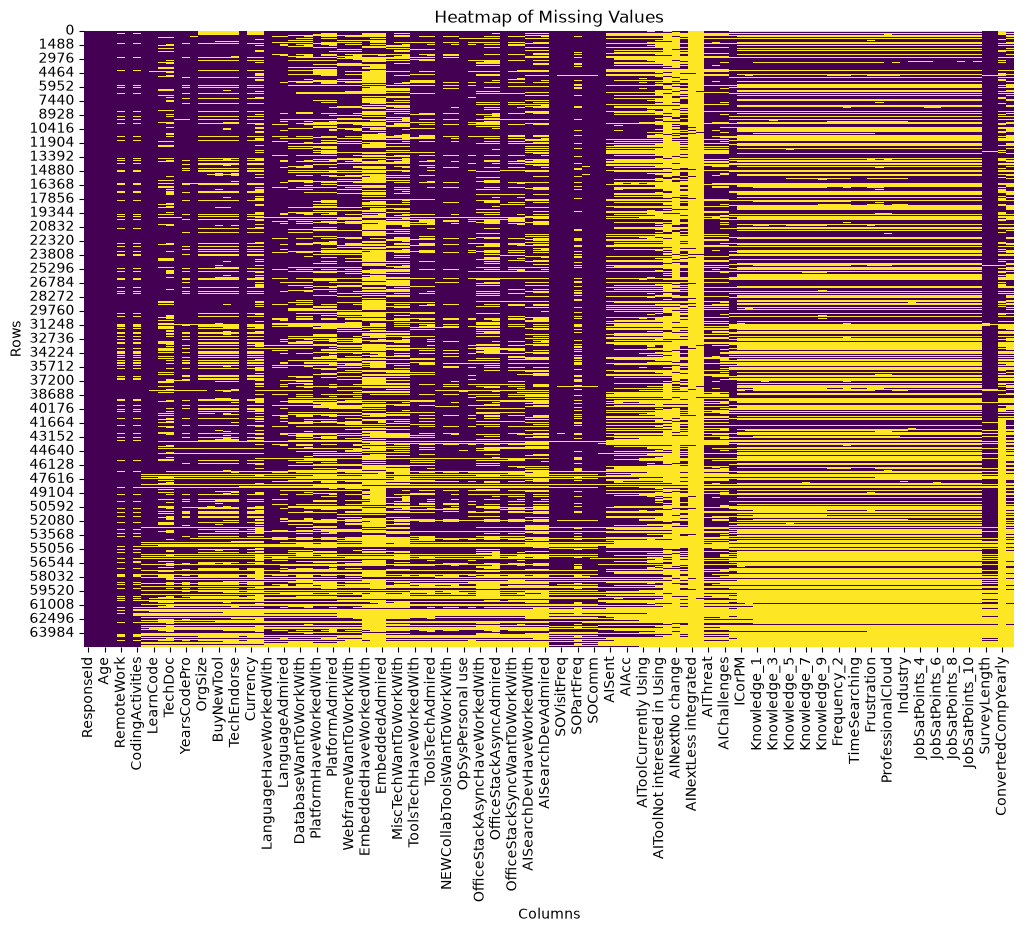

In [6]:
## Write your code here
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [10]:
## Write your code here
# Count the number of missing rows for the 'RemoteWork' column
#missing_RemoteWork = df['RemoteWork'].isnull().sum()
missing_Employee = df['Employment'].isnull().sum()
print(f"Number of missing rows in the 'RemoteWork' column: {missing_Employee}")

Number of missing rows in the 'RemoteWork' column: 0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [11]:
## Write your code here
#Identify the most frequent (majority) value in a specific column (e.g., `Employment`).
most_frequent_employment = df['Employment'].mode()[0]
print(f"Most frequent value in 'Employment' column: {most_frequent_employment}")

Most frequent value in 'Employment' column: Employed, full-time


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [12]:
## Write your code here
## Write your code here
#impute missing values in the `Employment` column with the most frequent value
df['Employment'].fillna(most_frequent_employment, inplace=True)
# Display the DataFrame after imputing missing values in Employment
print("DataFrame after imputing missing values in Employment:")
print(df[['Employment']].head())

DataFrame after imputing missing values in Employment:
            Employment
0  Employed, full-time
1  Employed, full-time
2  Employed, full-time
3   Student, full-time
4   Student, full-time


C:\Users\Shamim\AppData\Local\Temp\ipykernel_2156\848558976.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Employment'].fillna(most_frequent_employment, inplace=True)


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


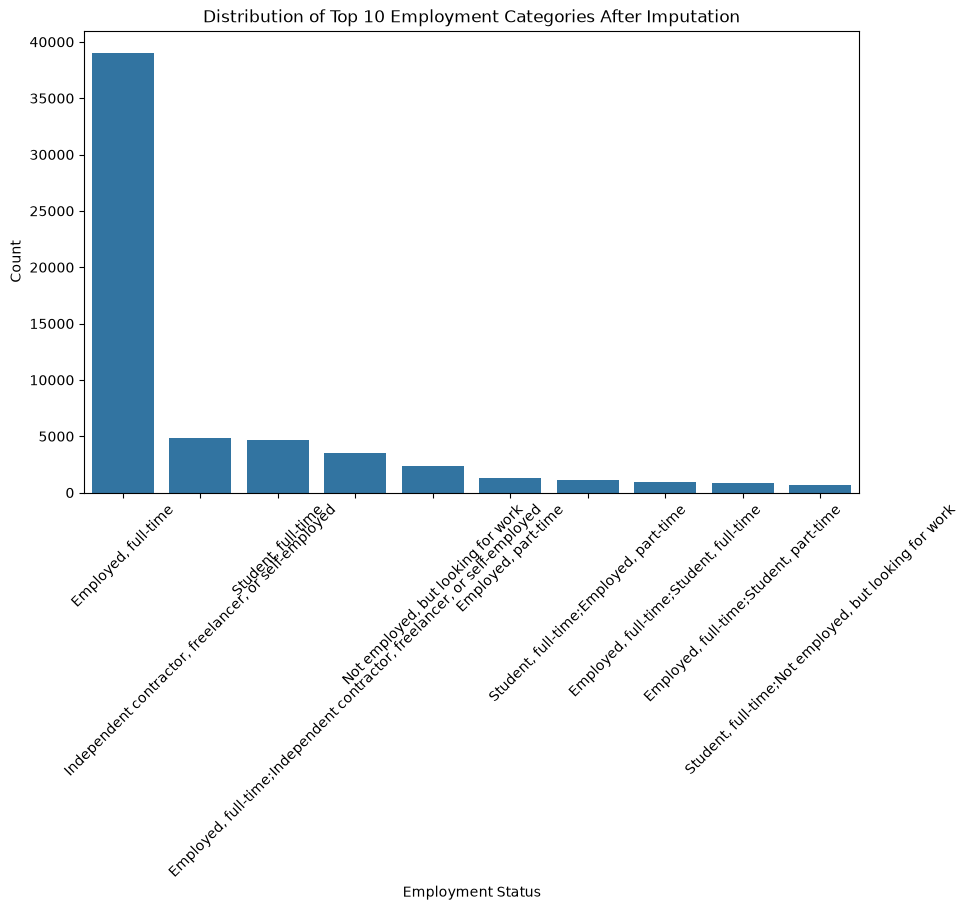

In [13]:
## Write your code here
#visualize the distribution of a column after imputation (e.g., Employment)
## Write your code here
# Visualize the distribution of a column after imputation (e.g., Employment) with only top 10 bins
top_10_employment = df['Employment'].value_counts().head(10).index
plt.figure(figsize=(10, 6)) 
sns.countplot(data=df[df['Employment'].isin(top_10_employment)], x='Employment', order=top_10_employment)
plt.title('Distribution of Top 10 Employment Categories After Imputation')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\Shamim\AppData\Local\Temp\ipykernel_2156\1580237392.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['ConvertedCompYearly'].fillna(median_value, inplace=True)


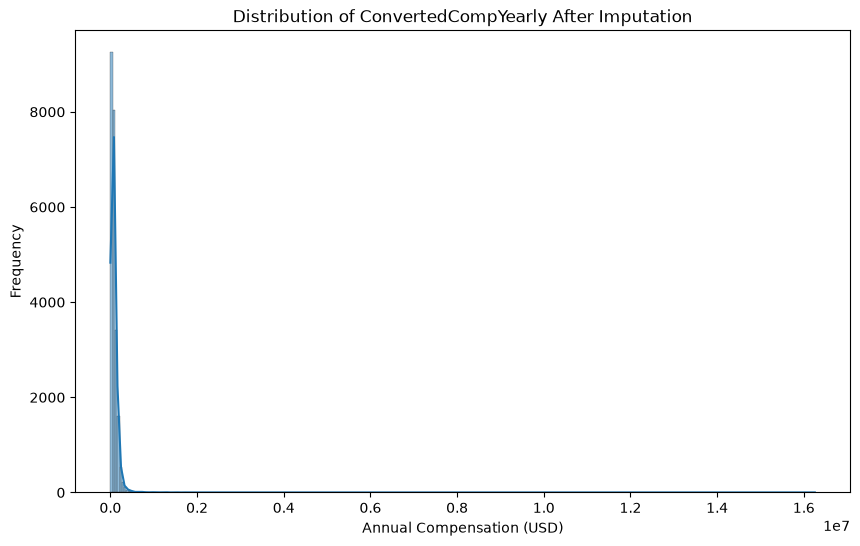

In [14]:
## Write your code here
# Handle missing values in ConvertedCompYearly by imputing with the median value
median_value = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'].fillna(median_value, inplace=True)

# Visualize the distribution of ConvertedCompYearly after imputation
plt.figure(figsize=(10, 6))
sns.histplot(df['ConvertedCompYearly'], kde=True)
plt.title('Distribution of ConvertedCompYearly After Imputation')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Frequency')
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
